# Laboratory Task 3 — Forward and Backward Propagation Using NumPy

**Understanding Deep Learning**

## Import Library

In [1]:
import numpy as np

## Define Input, Target, and Learning Rate

These are exactly the values specified by the laboratory instructions and Laboratory Task 2.

In [2]:
x = np.array([1.0, 0.0, 1.0])
y = np.array([1.0])

# Learning rate specified by the lab instructions
lr = 0.001

## Define Initial Weights and Biases

These are the exact values from Laboratory Task 2. The weight mapping follows the original lesson:

- Hidden neuron 1 uses weights $w_{11}$, $w_{13}$, $w_{15}$ and bias $\theta_1$.
- Hidden neuron 2 uses weights $w_{12}$, $w_{14}$, $w_{16}$ and bias $\theta_2$.
- The output neuron uses weights $w_{21}$, $w_{22}$ and bias $\theta_3$.

In [3]:
# Hidden unit weights
w11, w12 = 0.2, -0.3
w13, w14 = 0.4,  0.1
w15, w16 = -0.5, 0.2

# Output unit weights
w21 = -0.3
w22 = -0.2

# Biases
theta1 = -0.4
theta2 =  0.2
theta3 =  0.1

## ReLU Activation and Its Derivative

The ReLU activation function is:

$$f(z) = \max(0, z)$$

Its derivative, needed for backpropagation, is:

$$f'(z) = \begin{cases} 1, & z > 0 \\ 0, & z \leq 0 \end{cases}$$

The derivative is 1 wherever the neuron is active (positive input) and 0 wherever it is inactive. For this exercise, we define $f'(0) = 0$.

In [4]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

---
## Forward Propagation

We reproduce the same calculations from Task 2 programmatically.

In [5]:
# --- Hidden Layer ---
Z1 = (w11 * x[0]) + (w13 * x[1]) + (w15 * x[2]) + theta1
Z2 = (w12 * x[0]) + (w14 * x[1]) + (w16 * x[2]) + theta2

H1 = relu(Z1)
H2 = relu(Z2)

# --- Output Layer ---
Z3 = (w21 * H1) + (w22 * H2) + theta3
y_hat = relu(Z3)

print("=== Forward Propagation ===")
print(f"Z1 = {Z1}")
print(f"H1 = ReLU(Z1) = {H1}")
print(f"Z2 = {Z2}")
print(f"H2 = ReLU(Z2) = {H2}")
print(f"Z3 = {Z3}")
print(f"y_hat = ReLU(Z3) = {y_hat}")

=== Forward Propagation ===
Z1 = -0.7
H1 = ReLU(Z1) = 0.0
Z2 = 0.10000000000000003
H2 = ReLU(Z2) = 0.10000000000000003
Z3 = 0.08
y_hat = ReLU(Z3) = 0.08


## Error Calculation

Following the original notebook, the output error is:

$$\delta = \hat{y} - y$$

For deriving gradients, we adopt the **half-squared error** convention:

$$L = \frac{1}{2}(\hat{y} - y)^2$$

This is a common choice because its derivative with respect to $\hat{y}$ simplifies to:

$$\frac{\partial L}{\partial \hat{y}} = \hat{y} - y$$

which is exactly the error term $\delta$ used in the original notebook. Note: the original task did not explicitly prescribe this particular loss formulation — we adopt it here because it makes the error expression consistent with the gradient computation.

In [6]:
error = y_hat - y[0]
loss = 0.5 * error**2

print(f"Error (y_hat - y) = {error}")
print(f"Loss = 0.5*(y_hat - y)^2 = {loss}")

Error (y_hat - y) = -0.92
Loss = 0.5*(y_hat - y)^2 = 0.4232


---
## Backward Propagation

Backpropagation computes the gradient of the loss with respect to every weight and bias by applying the chain rule, working from the output layer back toward the input.

### Output Layer Delta

The delta for the output neuron combines the error signal with the ReLU derivative at $Z_3$:

$$\delta_3 = (\hat{y} - y) \cdot f'(Z_3)$$

The ReLU derivative checks whether $Z_3 > 0$. If $Z_3$ was positive during the forward pass, the derivative is 1 and the error passes through unchanged. If $Z_3$ was zero or negative, the gradient is blocked.

In [7]:
delta3 = error * relu_derivative(np.array(Z3))

print(f"ReLU'(Z3) = {relu_derivative(np.array(Z3))}")
print(f"delta3     = {delta3}")

ReLU'(Z3) = 1.0
delta3     = -0.92


### Output Weight Gradients

The gradients for the output weights and bias are:

$$\frac{\partial L}{\partial w_{21}} = \delta_3 \cdot H_1$$

$$\frac{\partial L}{\partial w_{22}} = \delta_3 \cdot H_2$$

$$\frac{\partial L}{\partial \theta_3} = \delta_3$$

In [8]:
dL_dw21 = delta3 * H1
dL_dw22 = delta3 * H2
dL_dtheta3 = delta3

print("=== Output Weight Gradients ===")
print(f"dL/dw21    = {dL_dw21}")
print(f"dL/dw22    = {dL_dw22}")
print(f"dL/dtheta3 = {dL_dtheta3}")

=== Output Weight Gradients ===
dL/dw21    = -0.0
dL/dw22    = -0.09200000000000004
dL/dtheta3 = -0.92


### Hidden Layer Deltas

The error is propagated back to each hidden neuron by multiplying the output delta by the connecting weight, then by the ReLU derivative at that hidden neuron's pre-activation:

$$\delta_1 = (\delta_3 \cdot w_{21}) \cdot f'(Z_1)$$

$$\delta_2 = (\delta_3 \cdot w_{22}) \cdot f'(Z_2)$$

If a hidden neuron was deactivated by ReLU during the forward pass (i.e., its $Z$ was negative), then $f'(Z) = 0$ and no gradient flows through that neuron.

In [9]:
delta1 = (delta3 * w21) * relu_derivative(np.array(Z1))
delta2 = (delta3 * w22) * relu_derivative(np.array(Z2))

print(f"ReLU'(Z1) = {relu_derivative(np.array(Z1))}  (neuron 1 was inactive)")
print(f"ReLU'(Z2) = {relu_derivative(np.array(Z2))}  (neuron 2 was active)")
print(f"delta1     = {delta1}")
print(f"delta2     = {delta2}")

ReLU'(Z1) = 0.0  (neuron 1 was inactive)
ReLU'(Z2) = 1.0  (neuron 2 was active)
delta1     = 0.0
delta2     = 0.18400000000000002


Because $Z_1 = -0.7 < 0$, hidden neuron 1 was inactive and $\delta_1 = 0$. All weight gradients connected to hidden neuron 1 will therefore be zero — ReLU blocks the gradient for inactive neurons.

### Hidden Weight Gradients

For hidden neuron 1 ($\delta_1 = 0$ in this case, so all gradients are zero):

$$\frac{\partial L}{\partial w_{11}} = \delta_1 \cdot x_1 \qquad \frac{\partial L}{\partial w_{13}} = \delta_1 \cdot x_2 \qquad \frac{\partial L}{\partial w_{15}} = \delta_1 \cdot x_3$$

$$\frac{\partial L}{\partial \theta_1} = \delta_1$$

For hidden neuron 2:

$$\frac{\partial L}{\partial w_{12}} = \delta_2 \cdot x_1 \qquad \frac{\partial L}{\partial w_{14}} = \delta_2 \cdot x_2 \qquad \frac{\partial L}{\partial w_{16}} = \delta_2 \cdot x_3$$

$$\frac{\partial L}{\partial \theta_2} = \delta_2$$

In [10]:
# Hidden neuron 1 gradients
dL_dw11 = delta1 * x[0]
dL_dw13 = delta1 * x[1]
dL_dw15 = delta1 * x[2]
dL_dtheta1 = delta1

# Hidden neuron 2 gradients
dL_dw12 = delta2 * x[0]
dL_dw14 = delta2 * x[1]
dL_dw16 = delta2 * x[2]
dL_dtheta2 = delta2

print("=== Hidden Weight Gradients ===")
print(f"dL/dw11    = {dL_dw11}")
print(f"dL/dw13    = {dL_dw13}")
print(f"dL/dw15    = {dL_dw15}")
print(f"dL/dtheta1 = {dL_dtheta1}")
print()
print(f"dL/dw12    = {dL_dw12}")
print(f"dL/dw14    = {dL_dw14}")
print(f"dL/dw16    = {dL_dw16}")
print(f"dL/dtheta2 = {dL_dtheta2}")

=== Hidden Weight Gradients ===
dL/dw11    = 0.0
dL/dw13    = 0.0
dL/dw15    = 0.0
dL/dtheta1 = 0.0

dL/dw12    = 0.18400000000000002
dL/dw14    = 0.0
dL/dw16    = 0.18400000000000002
dL/dtheta2 = 0.18400000000000002


---
## Update the Parameters

Each parameter is updated using gradient descent:

$$w_{\text{new}} = w_{\text{old}} - \alpha \cdot \frac{\partial L}{\partial w}$$

$$\theta_{\text{new}} = \theta_{\text{old}} - \alpha \cdot \frac{\partial L}{\partial \theta}$$

where $\alpha = 0.001$ is the learning rate.

In [11]:
print("=== Parameters BEFORE Update ===")
print(f"w11 = {w11},  w12 = {w12}")
print(f"w13 = {w13},  w14 = {w14}")
print(f"w15 = {w15},  w16 = {w16}")
print(f"w21 = {w21},  w22 = {w22}")
print(f"theta1 = {theta1}, theta2 = {theta2}, theta3 = {theta3}")

# Update hidden unit weights
w11 = w11 - lr * dL_dw11
w12 = w12 - lr * dL_dw12
w13 = w13 - lr * dL_dw13
w14 = w14 - lr * dL_dw14
w15 = w15 - lr * dL_dw15
w16 = w16 - lr * dL_dw16

# Update output unit weights
w21 = w21 - lr * dL_dw21
w22 = w22 - lr * dL_dw22

# Update biases
theta1 = theta1 - lr * dL_dtheta1
theta2 = theta2 - lr * dL_dtheta2
theta3 = theta3 - lr * dL_dtheta3

print("\n=== Parameters AFTER Update ===")
print(f"w11 = {w11},  w12 = {w12}")
print(f"w13 = {w13},  w14 = {w14}")
print(f"w15 = {w15},  w16 = {w16}")
print(f"w21 = {w21},  w22 = {w22}")
print(f"theta1 = {theta1}, theta2 = {theta2}, theta3 = {theta3}")

=== Parameters BEFORE Update ===
w11 = 0.2,  w12 = -0.3
w13 = 0.4,  w14 = 0.1
w15 = -0.5,  w16 = 0.2
w21 = -0.3,  w22 = -0.2
theta1 = -0.4, theta2 = 0.2, theta3 = 0.1

=== Parameters AFTER Update ===
w11 = 0.2,  w12 = -0.300184
w13 = 0.4,  w14 = 0.1
w15 = -0.5,  w16 = 0.19981600000000002
w21 = -0.3,  w22 = -0.199908
theta1 = -0.4, theta2 = 0.19981600000000002, theta3 = 0.10092000000000001


Notice that the weights connected to hidden neuron 1 ($w_{11}$, $w_{13}$, $w_{15}$, $\theta_1$) did not change because their gradients were zero — neuron 1 was deactivated by ReLU. The parameters that did change are those connected to hidden neuron 2 and the output layer.

---
## Second Forward Pass (After Update)

We now run the forward pass again with the updated parameters to check whether the prediction improved.

In [12]:
# --- Second Forward Pass ---
Z1_new = (w11 * x[0]) + (w13 * x[1]) + (w15 * x[2]) + theta1
Z2_new = (w12 * x[0]) + (w14 * x[1]) + (w16 * x[2]) + theta2

H1_new = relu(Z1_new)
H2_new = relu(Z2_new)

Z3_new = (w21 * H1_new) + (w22 * H2_new) + theta3
y_hat_new = relu(Z3_new)

error_new = y_hat_new - y[0]
loss_new = 0.5 * error_new**2

print("=== Second Forward Pass ===")
print(f"Z1  = {Z1_new}")
print(f"H1  = {H1_new}")
print(f"Z2  = {Z2_new}")
print(f"H2  = {H2_new}")
print(f"Z3  = {Z3_new}")
print(f"y_hat = {y_hat_new}")
print(f"Error = {error_new}")
print(f"Loss  = {loss_new}")

=== Second Forward Pass ===
Z1  = -0.7
H1  = 0.0
Z2  = 0.09944800000000004
H2  = 0.09944800000000004
Z3  = 0.081039549216
y_hat = 0.081039549216
Error = -0.918960450784
Loss  = 0.42224415505256624


## Result Comparison

In [13]:
print(f"{'Metric':<12} {'Before Update':>15} {'After Update':>15}")
print("-" * 44)
print(f"{'Prediction':<12} {0.08:>15.6f} {y_hat_new:>15.6f}")
print(f"{'Error':<12} {-0.92:>15.6f} {error_new:>15.6f}")
print(f"{'Loss':<12} {0.4232:>15.6f} {loss_new:>15.6f}")

Metric         Before Update    After Update
--------------------------------------------
Prediction          0.080000        0.081040
Error              -0.920000       -0.918960
Loss                0.423200        0.422244


The prediction moved slightly closer to the target, the absolute error decreased, and the loss decreased. Even though the change is very small (because the learning rate is 0.001 and only one update step was performed), the update moved the parameters in the correct direction.

---
## Optional Demonstration — Repeating Gradient Descent

The single step above demonstrates the core mechanism. Below we repeat the forward–backward–update cycle for multiple iterations to show how the prediction converges toward the target over time.

In [14]:
# Reset parameters to original values
w11, w12 = 0.2, -0.3
w13, w14 = 0.4,  0.1
w15, w16 = -0.5, 0.2
w21 = -0.3
w22 = -0.2
theta1 = -0.4
theta2 =  0.2
theta3 =  0.1

num_iterations = 1000
loss_history = []

for i in range(num_iterations):
    # Forward pass
    Z1 = (w11 * x[0]) + (w13 * x[1]) + (w15 * x[2]) + theta1
    Z2 = (w12 * x[0]) + (w14 * x[1]) + (w16 * x[2]) + theta2
    H1 = relu(Z1)
    H2 = relu(Z2)
    Z3 = (w21 * H1) + (w22 * H2) + theta3
    y_hat = relu(Z3)

    # Error and loss
    error = y_hat - y[0]
    loss = 0.5 * error**2
    loss_history.append(loss)

    # Backward pass
    delta3 = error * relu_derivative(np.array(Z3))
    dL_dw21 = delta3 * H1
    dL_dw22 = delta3 * H2
    dL_dtheta3 = delta3

    delta1 = (delta3 * w21) * relu_derivative(np.array(Z1))
    delta2 = (delta3 * w22) * relu_derivative(np.array(Z2))

    dL_dw11 = delta1 * x[0]
    dL_dw13 = delta1 * x[1]
    dL_dw15 = delta1 * x[2]
    dL_dtheta1 = delta1

    dL_dw12 = delta2 * x[0]
    dL_dw14 = delta2 * x[1]
    dL_dw16 = delta2 * x[2]
    dL_dtheta2 = delta2

    # Update parameters
    w11 -= lr * dL_dw11
    w12 -= lr * dL_dw12
    w13 -= lr * dL_dw13
    w14 -= lr * dL_dw14
    w15 -= lr * dL_dw15
    w16 -= lr * dL_dw16
    w21 -= lr * dL_dw21
    w22 -= lr * dL_dw22
    theta1 -= lr * dL_dtheta1
    theta2 -= lr * dL_dtheta2
    theta3 -= lr * dL_dtheta3

    if (i + 1) % 200 == 0 or i == 0:
        print(f"Iteration {i+1:>5d}  |  Prediction: {y_hat:.6f}  |  Loss: {loss:.6f}")

print(f"\nFinal prediction after {num_iterations} iterations: {y_hat:.6f}")
print(f"Final error: {y_hat - y[0]:.6f}")

Iteration     1  |  Prediction: 0.080000  |  Loss: 0.423200
Iteration   200  |  Prediction: 0.263388  |  Loss: 0.271299
Iteration   400  |  Prediction: 0.397638  |  Loss: 0.181420
Iteration   600  |  Prediction: 0.506877  |  Loss: 0.121585
Iteration   800  |  Prediction: 0.596306  |  Loss: 0.081485
Iteration  1000  |  Prediction: 0.669516  |  Loss: 0.054610

Final prediction after 1000 iterations: 0.669516
Final error: -0.330484


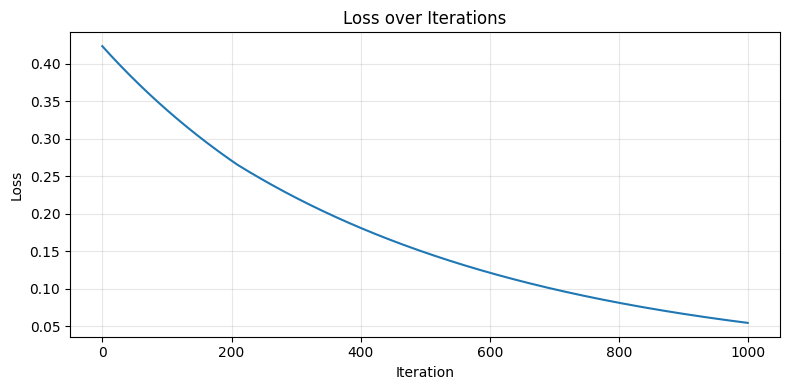

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Loss over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Conclusion

**Forward propagation** computed a prediction by passing the input through the hidden layer (applying weighted sums and ReLU activations) and then through the output layer. The initial prediction of $\hat{y} = 0.08$ was far from the target $y = 1$, producing an error of $\delta = -0.92$.

**Backward propagation** used the chain rule to calculate how much each weight and bias contributed to this error. The ReLU derivative played a key role: hidden neuron 1 was deactivated ($Z_1 < 0$), so its gradient was zero and its weights received no update. Only the active pathway (through hidden neuron 2 and the output neuron) contributed to learning.

**Gradient descent** then adjusted the active parameters by a small step proportional to the learning rate $\alpha = 0.001$. Even a single update reduced the loss, demonstrating the fundamental learning mechanism of neural networks. The optional multi-iteration extension showed that repeating this cycle gradually moves the prediction toward the target. This is the same core algorithm that PyTorch automates under the hood, which is explored in Laboratory Task 4.